**Experiment 4: Effect of Attention Heads, Positional Encoding and Context Length**

In [ ]:
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel

In [ ]:
# load a small transformer with attention outputs enabled
MODEL_NAME = "bert-base-uncased"

print(f"Loading model & tokenizer: {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME, output_attentions=True)
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"Running on device: {device}")
print(f"Model max context length (max_position_embeddings): "
      f"{model.config.max_position_embeddings} tokens\n")

Loading model & tokenizer: bert-base-uncased ...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Running on device: cpu
Model max context length (max_position_embeddings): 512 tokens



In [ ]:
# Prepare short, medium and long input texts
default_short = "The cat sat on the mat."

default_medium = (
    "The cat sat on the mat because it was tired after playing all "
    "afternoon in the garden with the neighbor's dog."
)

default_long = (
    "The cat sat on the mat because it was tired after playing all "
    "afternoon in the garden with the neighbor's dog. Later that evening, "
    "the family gathered in the living room to watch a movie together, "
    "while the cat curled up near the fireplace and slowly drifted off "
    "to sleep, dreaming about chasing birds through the tall grass near "
    "the old oak tree at the edge of the yard, where it often spent its "
    "mornings hunting for insects and watching the neighborhood children "
    "walk to school every day before the sun rose too high in the sky."
)

print("[Step 1] Enter your own texts, or press Enter to use defaults.\n")
short_text = input(f"Short text (Enter for default): ").strip() or default_short
medium_text = input(f"Medium text (Enter for default): ").strip() or default_medium
long_text = input(f"Long text (Enter for default): ").strip() or default_long

texts = {
    "short": short_text,
    "medium": medium_text,
    "long": long_text,
}

for label, text in texts.items():
    print(f"\n[{label.upper()}] ({len(text.split())} words): {text}")

[Step 1] Enter your own texts, or press Enter to use defaults.

Short text (Enter for default): 
Medium text (Enter for default): 
Long text (Enter for default): 

[SHORT] (6 words): The cat sat on the mat.

[MEDIUM] (21 words): The cat sat on the mat because it was tired after playing all afternoon in the garden with the neighbor's dog.

[LONG] (97 words): The cat sat on the mat because it was tired after playing all afternoon in the garden with the neighbor's dog. Later that evening, the family gathered in the living room to watch a movie together, while the cat curled up near the fireplace and slowly drifted off to sleep, dreaming about chasing birds through the tall grass near the old oak tree at the edge of the yard, where it often spent its mornings hunting for insects and watching the neighborhood children walk to school every day before the sun rose too high in the sky.


In [ ]:
# Tokenize each text and record token counts
# Run inference and record approximate latency/memory
results = []
all_attentions = {}
all_tokens = {}

for label, text in texts.items():
    inputs = tokenizer(text, return_tensors="pt").to(device)
    token_list = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    token_count = len(token_list)

    # reset GPU memory stats if on GPU
    if device == "cuda":
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    start_time = time.time()
    with torch.no_grad():
        outputs = model(**inputs)
    if device == "cuda":
        torch.cuda.synchronize()
    latency_ms = (time.time() - start_time) * 1000

    if device == "cuda":
        peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
    else:
        peak_mem_mb = None  # not straightforward to measure precisely on CPU

    results.append({
        "input_type": label,
        "word_count": len(text.split()),
        "token_count": token_count,
        "latency_ms": round(latency_ms, 3),
        "peak_gpu_mem_MB": round(peak_mem_mb, 2) if peak_mem_mb else "N/A (CPU)",
    })

    all_attentions[label] = outputs.attentions
    all_tokens[label] = token_list

    print(f"[Step 2-3] {label}: {token_count} tokens, "
          f"{latency_ms:.2f} ms inference time")

df = pd.DataFrame(results)
print("\n[Step 2-3] Summary table:\n")
print(df.to_string(index=False))

[Step 2-3] short: 9 tokens, 1081.36 ms inference time
[Step 2-3] medium: 26 tokens, 734.09 ms inference time
[Step 2-3] long: 107 tokens, 3153.25 ms inference time

[Step 2-3] Summary table:

input_type  word_count  token_count  latency_ms peak_gpu_mem_MB
     short           6            9    1081.363       N/A (CPU)
    medium          21           26     734.093       N/A (CPU)
      long          97          107    3153.253       N/A (CPU)



[Step 4-5] Plotting attention (layer 11, head 0) for short / medium / long inputs side by side ...


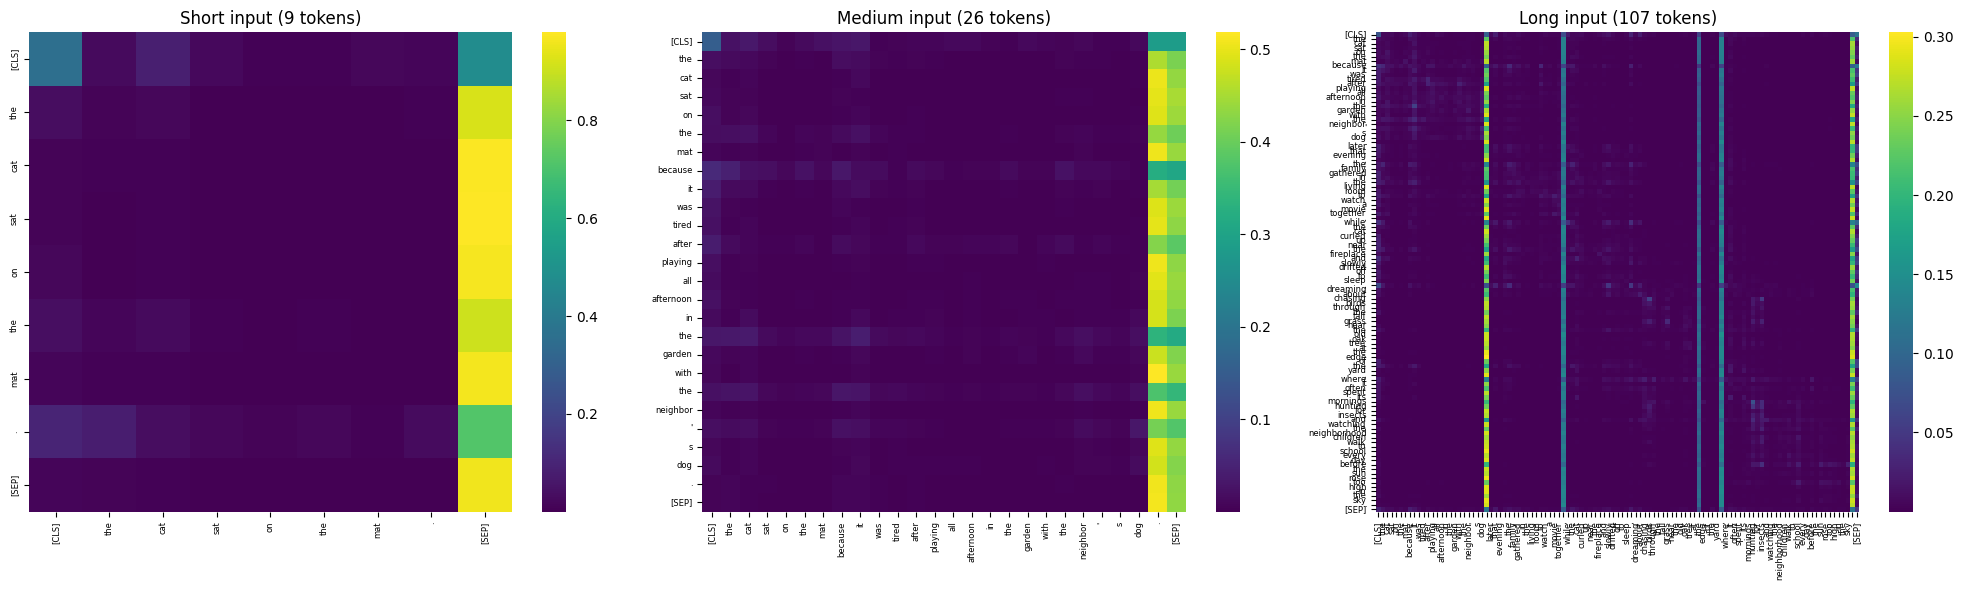

In [ ]:
# Inspect selected attention heads for each input
# Compare token interactions across heads
layer_idx = model.config.num_hidden_layers - 1   # last layer by default
head_idx = 0                                      # first head by default

print(f"\n[Step 4-5] Plotting attention (layer {layer_idx}, head {head_idx}) "
      f"for short / medium / long inputs side by side ...")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, label in enumerate(["short", "medium", "long"]):
    attn_matrix = all_attentions[label][layer_idx][0, head_idx].cpu().numpy()
    tks = all_tokens[label]
    sns.heatmap(
        attn_matrix,
        xticklabels=tks,
        yticklabels=tks,
        cmap="viridis",
        cbar=True,
        ax=axes[i],
    )
    axes[i].set_title(f"{label.capitalize()} input ({len(tks)} tokens)")
    axes[i].tick_params(axis='x', rotation=90, labelsize=6)
    axes[i].tick_params(axis='y', labelsize=6)

plt.tight_layout()
plt.savefig("attention_by_input_length.png", dpi=150)
plt.show()

In [ ]:
# Discuss the role of positional information
# Demonstration: shuffle the token order of the SHORT text and see how the
# model's output embeddings change, to illustrate that self-attention alone
# (without positional encoding) treats input as a "bag of tokens".
print("\n[Step 6] Demonstrating the role of positional information...")

import random

short_inputs = tokenizer(short_text, return_tensors="pt").to(device)
input_ids = short_inputs["input_ids"][0].tolist()

# Keep [CLS] and [SEP] fixed, shuffle the middle tokens
cls_id, sep_id = input_ids[0], input_ids[-1]
middle = input_ids[1:-1]
shuffled_middle = middle.copy()
random.shuffle(shuffled_middle)
shuffled_ids = [cls_id] + shuffled_middle + [sep_id]

original_tensor = torch.tensor([input_ids]).to(device)
shuffled_tensor = torch.tensor([shuffled_ids]).to(device)

with torch.no_grad():
    orig_out = model(input_ids=original_tensor).last_hidden_state
    shuf_out = model(input_ids=shuffled_tensor).last_hidden_state

# Compare the [CLS] embedding (sentence-level representation) before/after shuffle
cls_diff = torch.norm(orig_out[0, 0] - shuf_out[0, 0]).item()

print(f"[Step 6] Original tokens : {tokenizer.convert_ids_to_tokens(input_ids)}")
print(f"[Step 6] Shuffled tokens : {tokenizer.convert_ids_to_tokens(shuffled_ids)}")
print(f"[Step 6] L2 distance between [CLS] embeddings "
      f"(original vs shuffled word order): {cls_diff:.4f}")
print("[Step 6] A large, non-zero distance shows the model's output DOES "
      "change when word order changes -- this change comes from the "
      "positional embeddings added before the first attention layer. "
      "Without them, self-attention would give the identical result for "
      "any permutation of the same tokens (attention itself is "
      "permutation-invariant).")


[Step 6] Demonstrating the role of positional information...
[Step 6] Original tokens : ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '.', '[SEP]']
[Step 6] Shuffled tokens : ['[CLS]', 'cat', 'the', 'on', 'the', 'sat', '.', 'mat', '[SEP]']
[Step 6] L2 distance between [CLS] embeddings (original vs shuffled word order): 6.2356
[Step 6] A large, non-zero distance shows the model's output DOES change when word order changes -- this change comes from the positional embeddings added before the first attention layer. Without them, self-attention would give the identical result for any permutation of the same tokens (attention itself is permutation-invariant).



[Step 7] Model's max context window: 512 tokens


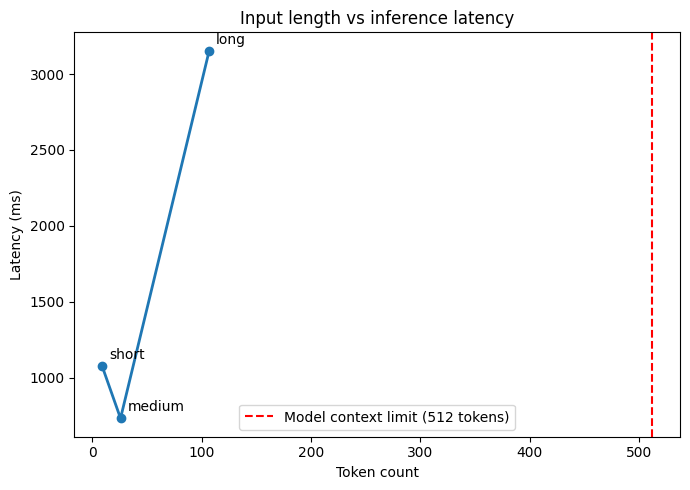

In [ ]:
# Relate input length to context-window limits and computational cost
print(f"\n[Step 7] Model's max context window: "
      f"{model.config.max_position_embeddings} tokens")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(df["token_count"], df["latency_ms"], marker="o", linewidth=2)
for _, row in df.iterrows():
    ax.annotate(row["input_type"], (row["token_count"], row["latency_ms"]),
                textcoords="offset points", xytext=(5, 5))
ax.set_xlabel("Token count")
ax.set_ylabel("Latency (ms)")
ax.set_title("Input length vs inference latency")
ax.axvline(model.config.max_position_embeddings, color="red", linestyle="--",
           label=f"Model context limit ({model.config.max_position_embeddings} tokens)")
ax.legend()
plt.tight_layout()
plt.savefig("length_vs_latency.png", dpi=150)
plt.show()

In [ ]:
print("""
[Step 7] Note: self-attention's compute/memory cost scales roughly with the
SQUARE of the sequence length (O(n^2)), because every token attends to
every other token. So as input length grows toward the model's context
window limit, both latency and memory usage grow much faster than linearly.
""")


[Step 7] Note: self-attention's compute/memory cost scales roughly with the
SQUARE of the sequence length (O(n^2)), because every token attends to
every other token. So as input length grows toward the model's context
window limit, both latency and memory usage grow much faster than linearly.



--- Summary Result Table ---


,input_type,word_count,token_count,latency_ms,peak_gpu_mem_MB
0,short,6,9,1081.363,N/A (CPU)
1,medium,21,26,734.093,N/A (CPU)
2,long,97,107,3153.253,N/A (CPU)



--- Attention Heatmaps for Different Lengths ---


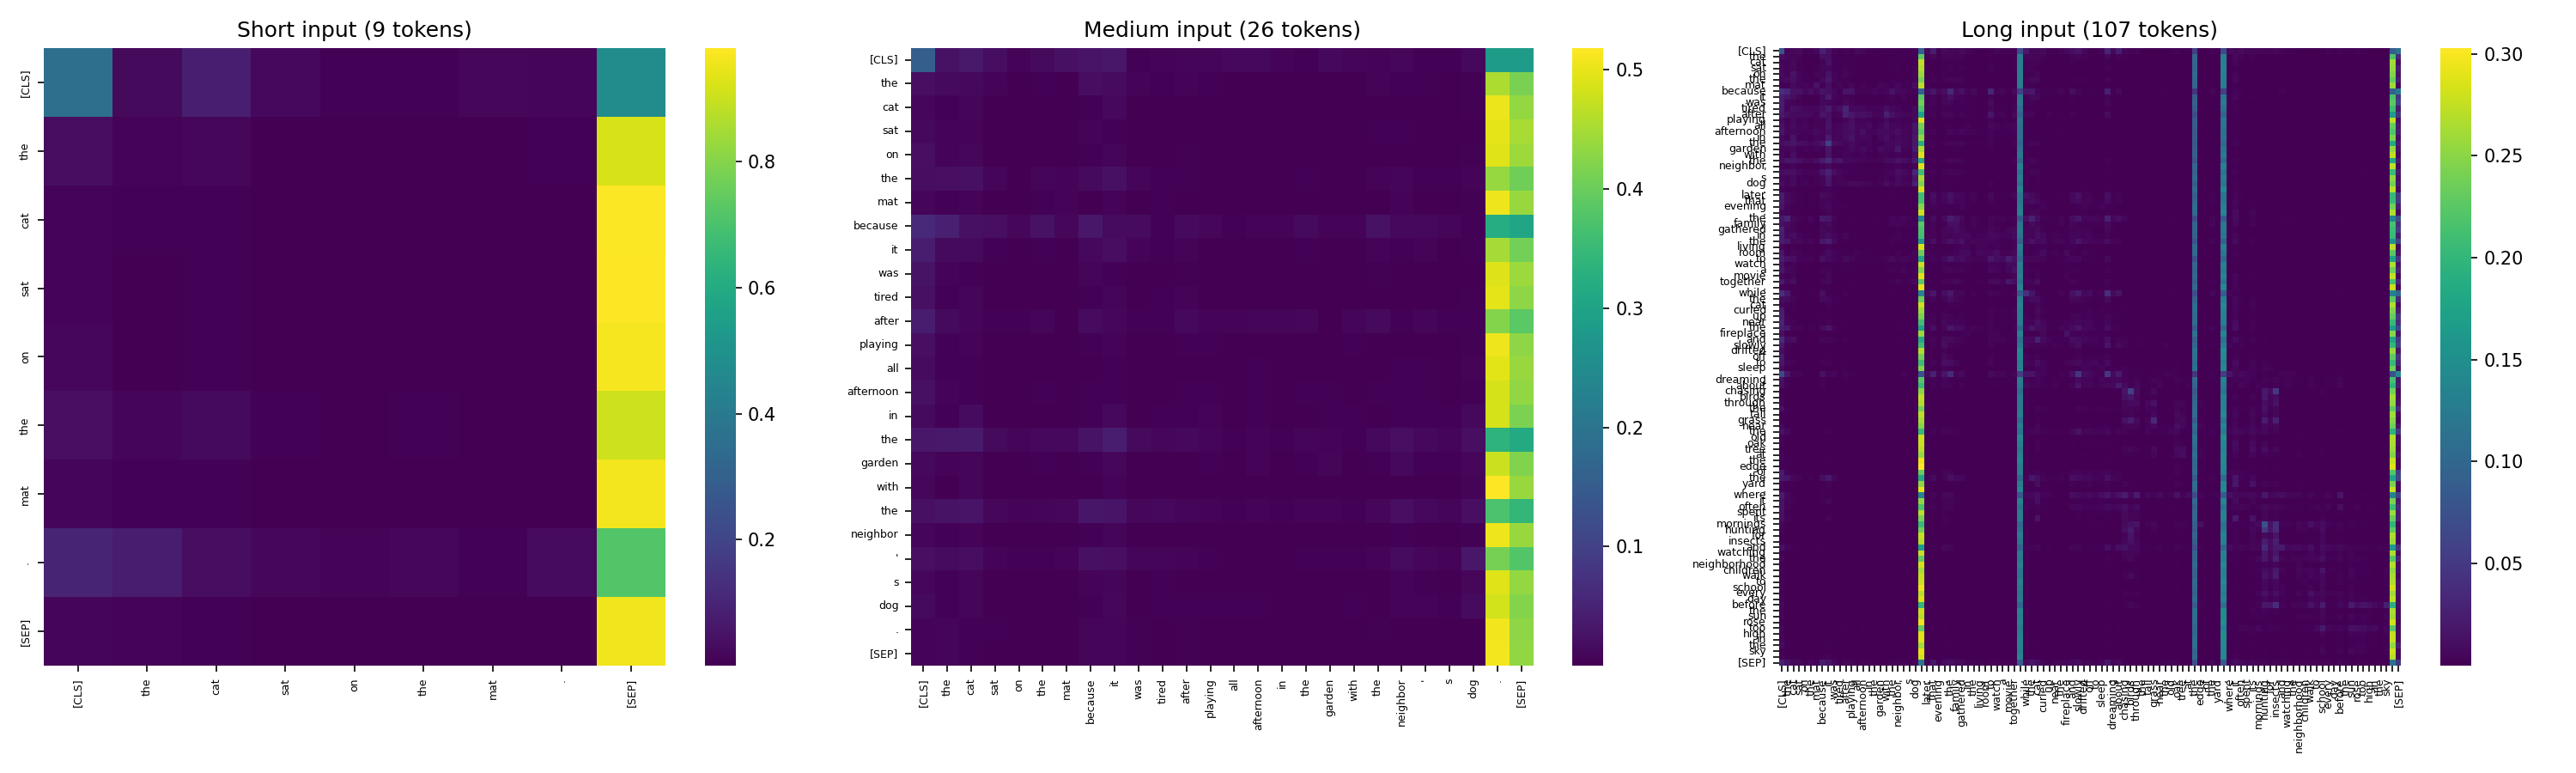


--- Token Count vs. Inference Latency ---


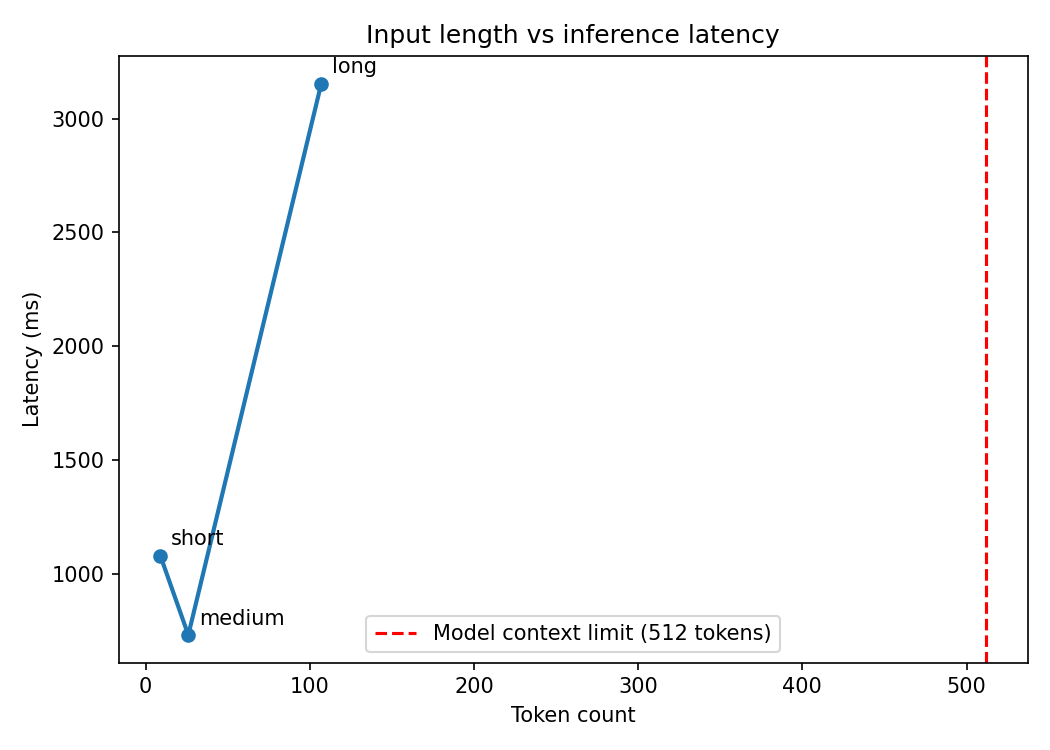

In [ ]:
from IPython.display import display, Image

print("--- Summary Result Table ---")
display(df)

print("\n--- Attention Heatmaps for Different Lengths ---")
display(Image(filename='attention_by_input_length.png'))

print("\n--- Token Count vs. Inference Latency ---")
display(Image(filename='length_vs_latency.png'))